<a href="https://colab.research.google.com/github/siwarTaha/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: Prediction of Product Sales

Siwar Ehwass

## Project Overview

### Data Dictionary

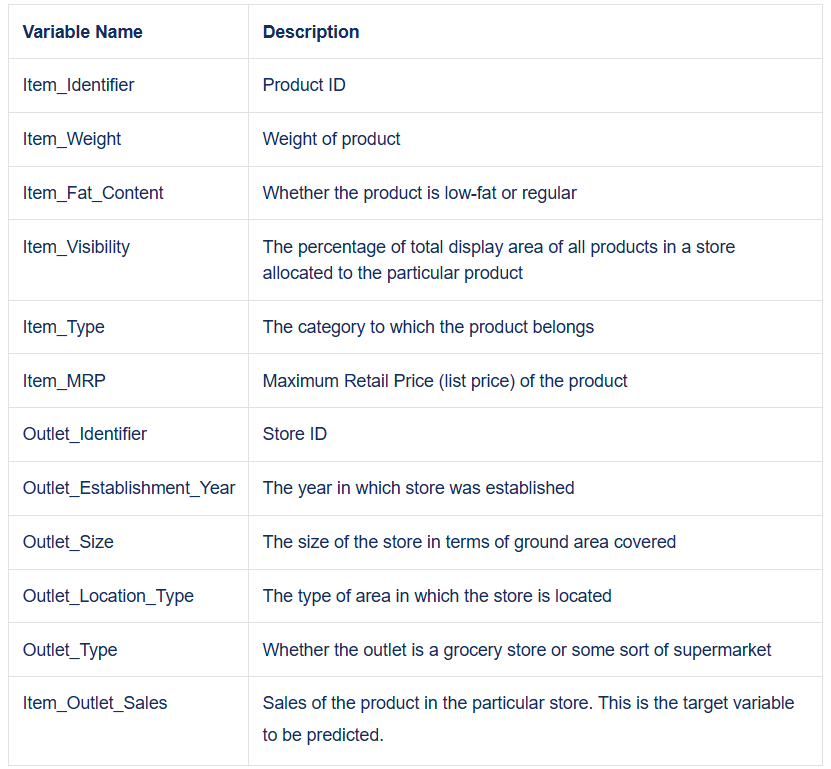

## Load and Inspect Data

### Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import set_config

set_config(transform_output='pandas')

### Loading Data

In [ ]:
path='https://docs.google.com/spreadsheets/d/e/2PACX-1vR6AvAZumX2EE8diEPYfNdktYpa8cELog1Iv_SL7EIFj_DIVxnGwq5liujvJ1GTQry9NDkFsISbeWaE/pub?output=csv'
df=pd.read_csv(path)


In [ ]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


### Feature Engineering

The following feature engineering steps have been applied to the `df` DataFrame immediately after loading the data to ensure they are available before the train-test split.

*   **`Outlet_Age`**: Calculated as `2026 - Outlet_Establishment_Year`.
*   **`Item_Category`**: Extracted from the first two characters of `Item_Identifier`.
*   **Non-Edible `Item_Fat_Content`**: Items with `Item_Category` 'NC' (Non-Consumable) have their `Item_Fat_Content` standardized to 'Non-Edible'.
*   **Dropped high-cardinality IDs**: `Item_Identifier` and `Outlet_Identifier` columns were dropped.
*   **Standardized `Item_Fat_Content` values**: Inconsistent values ('LF', 'reg', 'low fat') were standardized to 'Low Fat' and 'Regular'.

In [ ]:

# Create Outlet_Age and drop Outlet_Establishment_Year
df['Outlet_Age'] = 2026 - df['Outlet_Establishment_Year']
df.drop(columns=['Outlet_Establishment_Year'], inplace=True)

# Extract Item_Category from Item_Identifier
df['Item_Category'] = df['Item_Identifier'].str[:2]

# Set non-consumable items to 'Non-Edible' fat content
df.loc[df['Item_Category'] == 'NC', 'Item_Fat_Content'] = 'Non-Edible'

# Drop Item_Identifier and Outlet_Identifier
df.drop(columns=['Item_Identifier','Outlet_Identifier'], inplace=True)

# Replace inconsistent Item_Fat_Content values
df['Item_Fat_Content']=df['Item_Fat_Content'].replace({'LF':'Low Fat',
                                             "low fat":'Low Fat',
                                             'reg':'Regular'})

### Train test split

In [ ]:
# target column
y= df['Item_Outlet_Sales']
X= df.drop(columns='Item_Outlet_Sales')

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Replace 0s in Item_Visibility with np.nan for imputation by pipeline
X_train.loc[X_train['Item_Visibility'] == 0, 'Item_Visibility'] = np.nan
X_test.loc[X_test['Item_Visibility'] == 0, 'Item_Visibility'] = np.nan

### Handling `Item_Visibility`

*   **`Item_Visibility`**: Values of `0` in `Item_Visibility` are treated as missing data (`np.nan`) *after* the train-test split for `X_train` and `X_test`. This allows the `SimpleImputer` within the numeric pipeline to handle these `NaN` values (e.g., by median imputation) during model training and evaluation.


## Clean Data

### Duplicated Rows

In [ ]:
# check for duplicated data
print(X_train.duplicated().sum())
print(X_test.duplicated().sum())

0
0


- there are no duplicated values



### Unique Identifiers

In [ ]:
# percentage of unique values in each column for X_train
print("Percentage of unique values in X_train:\n",X_train.nunique() / len(X_train) * 100)

print("\nPercentage of unique values in X_test:\n",X_test.nunique() / len(X_test) * 100)

Percentage of unique values in X_train:
 Item_Weight              6.445557
Item_Fat_Content         0.046934
Item_Visibility         92.709637
Item_Type                0.250313
Item_MRP                76.048185
Outlet_Size              0.046934
Outlet_Location_Type     0.046934
Outlet_Type              0.062578
Outlet_Age               0.140801
Item_Category            0.046934
dtype: float64

Percentage of unique values in X_test:
 Item_Weight             16.705772
Item_Fat_Content         0.140779
Item_Visibility         93.664946
Item_Type                0.750821
Item_MRP                90.614735
Outlet_Size              0.140779
Outlet_Location_Type     0.140779
Outlet_Type              0.187705
Outlet_Age               0.422337
Item_Category            0.140779
dtype: float64


**Notes:**
- It is noticeable that `Item_Visibility` and `Item_MRP` have really high variance, however we are not going to drop them as they are useful for training the model later.

### Missing Values
- Checking for NaN rows:

In [ ]:
# see columns and rows where NaN is present in X_train
X_train.isna().sum()

,0
Item_Weight,1107
Item_Fat_Content,0
Item_Visibility,400
Item_Type,0
Item_MRP,0
Outlet_Size,1812
Outlet_Location_Type,0
Outlet_Type,0
Outlet_Age,0
Item_Category,0


**Note:**

- we will impute the following:
  - Item_Weight (float)
  - Item_Visibility (int)
  - Outlet_Size (cat)

- **Side Note**
  - some `Item_Visibility` items that are equal to 0 has been replaced with a null value, to later impute it with median in the pipeline.



#### Inspect Outlet Size

In [ ]:
# filter categorical features from X_train
cat_cols=X_train.select_dtypes('object').columns

# filter numerical features from X_train
num_cols=X_train.select_dtypes('number').columns

In [ ]:
X_train['Outlet_Size'].value_counts(dropna=False)

,count
Outlet_Size,
Medium,2103
NaN,1812
Small,1788
High,689


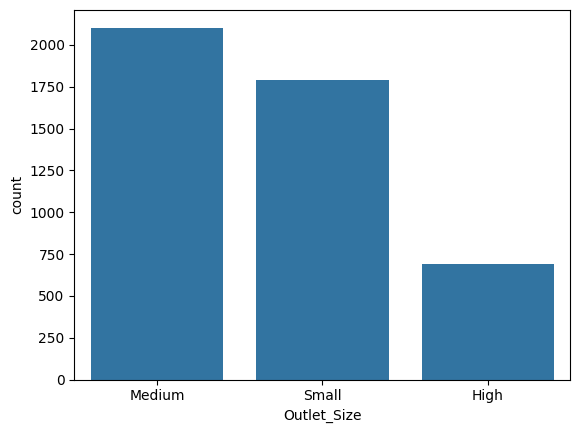

In [ ]:
ax=sns.countplot(data=X_train, x='Outlet_Size')

- This graph shows that there are over 2000 Medium and Small Outlets Size while there are less than 1000 High Outlet size.

- Since Outlet_Size is a categorical feature with a large percentage of missing values (~28%):
  - dropping rows would result in significant data loss.
  - Filling with the most frequent category could introduce bias into the distribution.
  - Therefore, replacing missing values with "MISSING" is the most appropriate strategy because it preserves the data

#### Inspecting Item Weight

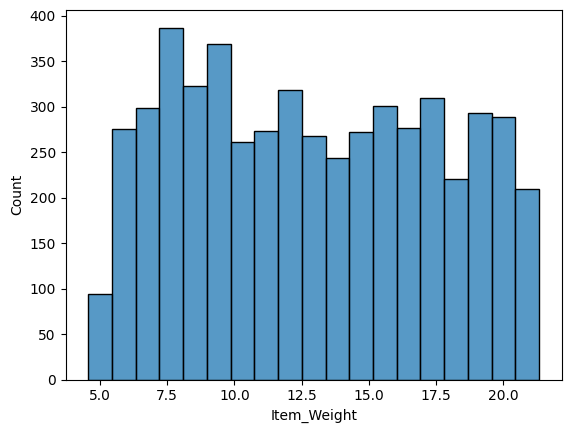

In [ ]:
ax = sns.histplot(data=X_train,x='Item_Weight')

- Median is preferred because it is less affected by outliers and preserves the distribution better than using -1 or dropping rows.

- Since Item Weight is a numeric feature, missing values were filled using the median because it is less affected by outliers and helps preserve the overall distribution of the data.

Before filling number columns with any value, check describe()

In [ ]:
cat_cols=X_train.select_dtypes('object').columns
num_cols=X_train.select_dtypes('number').columns

In [ ]:
# summary of num cols in X_train
for col in num_cols:
  print(f'summary of {col}: ')
  print(X_train[col].describe())
  print("\n")

summary of Item_Weight: 
count    5285.000000
mean       12.904458
std         4.637034
min         4.555000
25%         8.895000
50%        12.650000
75%        17.000000
max        21.350000
Name: Item_Weight, dtype: float64


summary of Item_Visibility: 
count    5992.000000
mean        0.070413
std         0.049785
min         0.003575
25%         0.031712
50%         0.058208
75%         0.097916
max         0.328391
Name: Item_Visibility, dtype: float64


summary of Item_MRP: 
count    6392.000000
mean      141.980400
std        62.629276
min        31.290000
25%        94.146200
50%       144.110200
75%       186.900300
max       266.888400
Name: Item_MRP, dtype: float64


summary of Outlet_Age: 
count    6392.000000
mean       28.142835
std         8.392300
min        17.000000
25%        22.000000
50%        27.000000
75%        39.000000
max        41.000000
Name: Outlet_Age, dtype: float64




nothing needs to be addressed, so we will impute later in the pipeline

### Consistent Values

Check each string column's value counts for inconsistent values:


In [ ]:
# loop through each categorical/string column in X_train
for col in cat_cols:
  print(f'value counts of {col}: ')
  print(X_train[col].value_counts())
  print("\n")

value counts of Item_Fat_Content: 
Item_Fat_Content
Low Fat       2914
Regular       2263
Non-Edible    1215
Name: count, dtype: int64


value counts of Item_Type: 
Item_Type
Fruits and Vegetables    948
Snack Foods              906
Household                695
Frozen Foods             632
Dairy                    507
Canned                   481
Baking Goods             478
Health and Hygiene       390
Soft Drinks              331
Meat                     302
Breads                   175
Hard Drinks              169
Others                   130
Starchy Foods            122
Breakfast                 84
Seafood                   42
Name: count, dtype: int64


value counts of Outlet_Size: 
Outlet_Size
Medium    2103
Small     1788
High       689
Name: count, dtype: int64


value counts of Outlet_Location_Type: 
Outlet_Location_Type
Tier 3    2531
Tier 2    2106
Tier 1    1755
Name: count, dtype: int64


value counts of Outlet_Type: 
Outlet_Type
Supermarket Type1    4166
Grocery Store    

This column has incosistent values:
- Fat Content: LF, reg, low fat
- fixed at the start when importing the df to not cause data leakage

In [ ]:
# check for inconsistent values in X_train
X_train['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,2914
Regular,2263
Non-Edible,1215


- as addressed before, for non-consumable categories, the fat content of the NC items, their `Item_Fat_Content` is replaced with `Non-Edible` to not confuse the model.

### Describe Numeric Data
- min, max, mean

In [ ]:
# get numeric columns from X_train
num_cols_df=X_train.select_dtypes('number').columns

# use the describe method and filter using .loc() on X_train
X_train[num_cols_df].describe().loc[['min','max','mean']]

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Age
min,4.555000,0.003575,31.2900,17.000000
max,21.350000,0.328391,266.8884,41.000000
mean,12.904458,0.070413,141.9804,28.142835


## Feature Inspection
- Exploratory Visuals & Analysis

In [ ]:
# view X_train data
X_train.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Age,Item_Category
4776,16.350,Non-Edible,0.029565,Household,256.4646,Medium,Tier 3,Supermarket Type2,17,NC
7510,15.250,Regular,NaN,Snack Foods,179.7660,Medium,Tier 3,Supermarket Type2,17,FD
5828,12.350,Regular,0.158716,Meat,157.2946,Medium,Tier 1,Supermarket Type1,27,FD
5327,7.975,Low Fat,0.014628,Baking Goods,82.3250,Small,Tier 2,Supermarket Type1,22,FD
4810,19.350,Low Fat,0.016645,Frozen Foods,120.9098,NaN,Tier 2,Supermarket Type1,24,FD


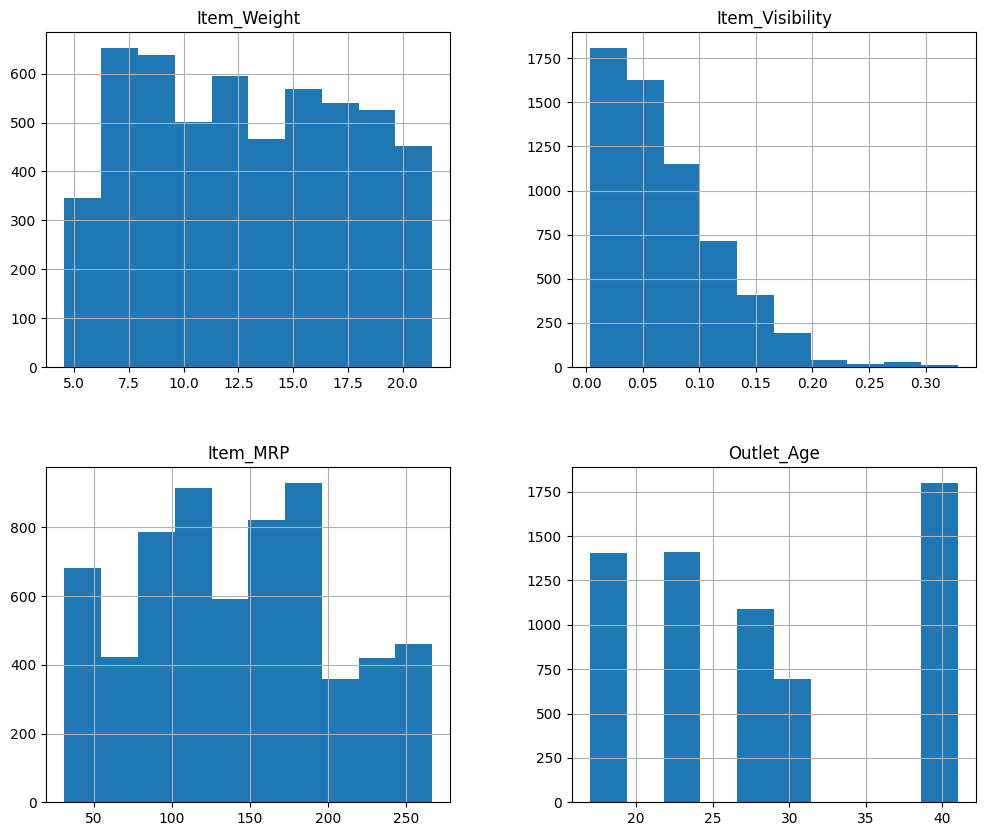

In [ ]:
ax=X_train.hist(figsize=(12,10));

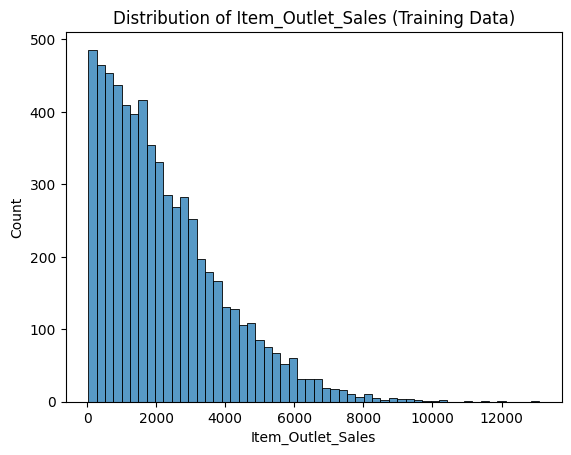

In [ ]:
# item outlet sales (from y_train)
ax= sns.histplot(x=y_train)
ax.set_title("Distribution of Item_Outlet_Sales (Training Data)");

- Most items have low visibility.
- Most sales are low, with a few very high sales.
- Retail prices vary a lot.

- **Sales:**
  - Most products have low sales.
  - The distribution is right-skewed.
  - A few products have very high sales (outliers).

### Boxplot for numeric columns

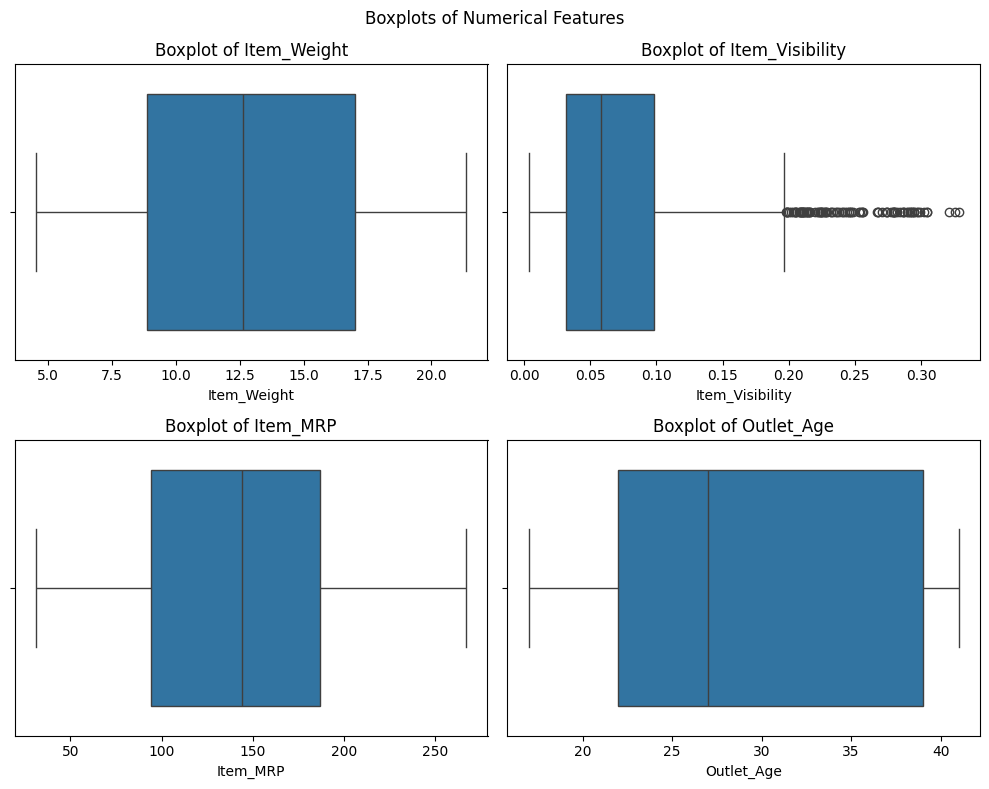

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=X_train[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}", fontsize=12)
    axes[i].set_xlabel(col)

# Remove empty plots if num_cols has less than 4 columns
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Boxplots of Numerical Features")
fig.tight_layout();

What we notice from the boxplots:

- Item_Visibility has many outliers (many unusually high values).
- Item_Outlet_Sales also has many high outliers.
- Item_Weight and Maximum Retail Price are more evenly spread.
- Bigger boxes mean more spread in the middle 50% of the data.

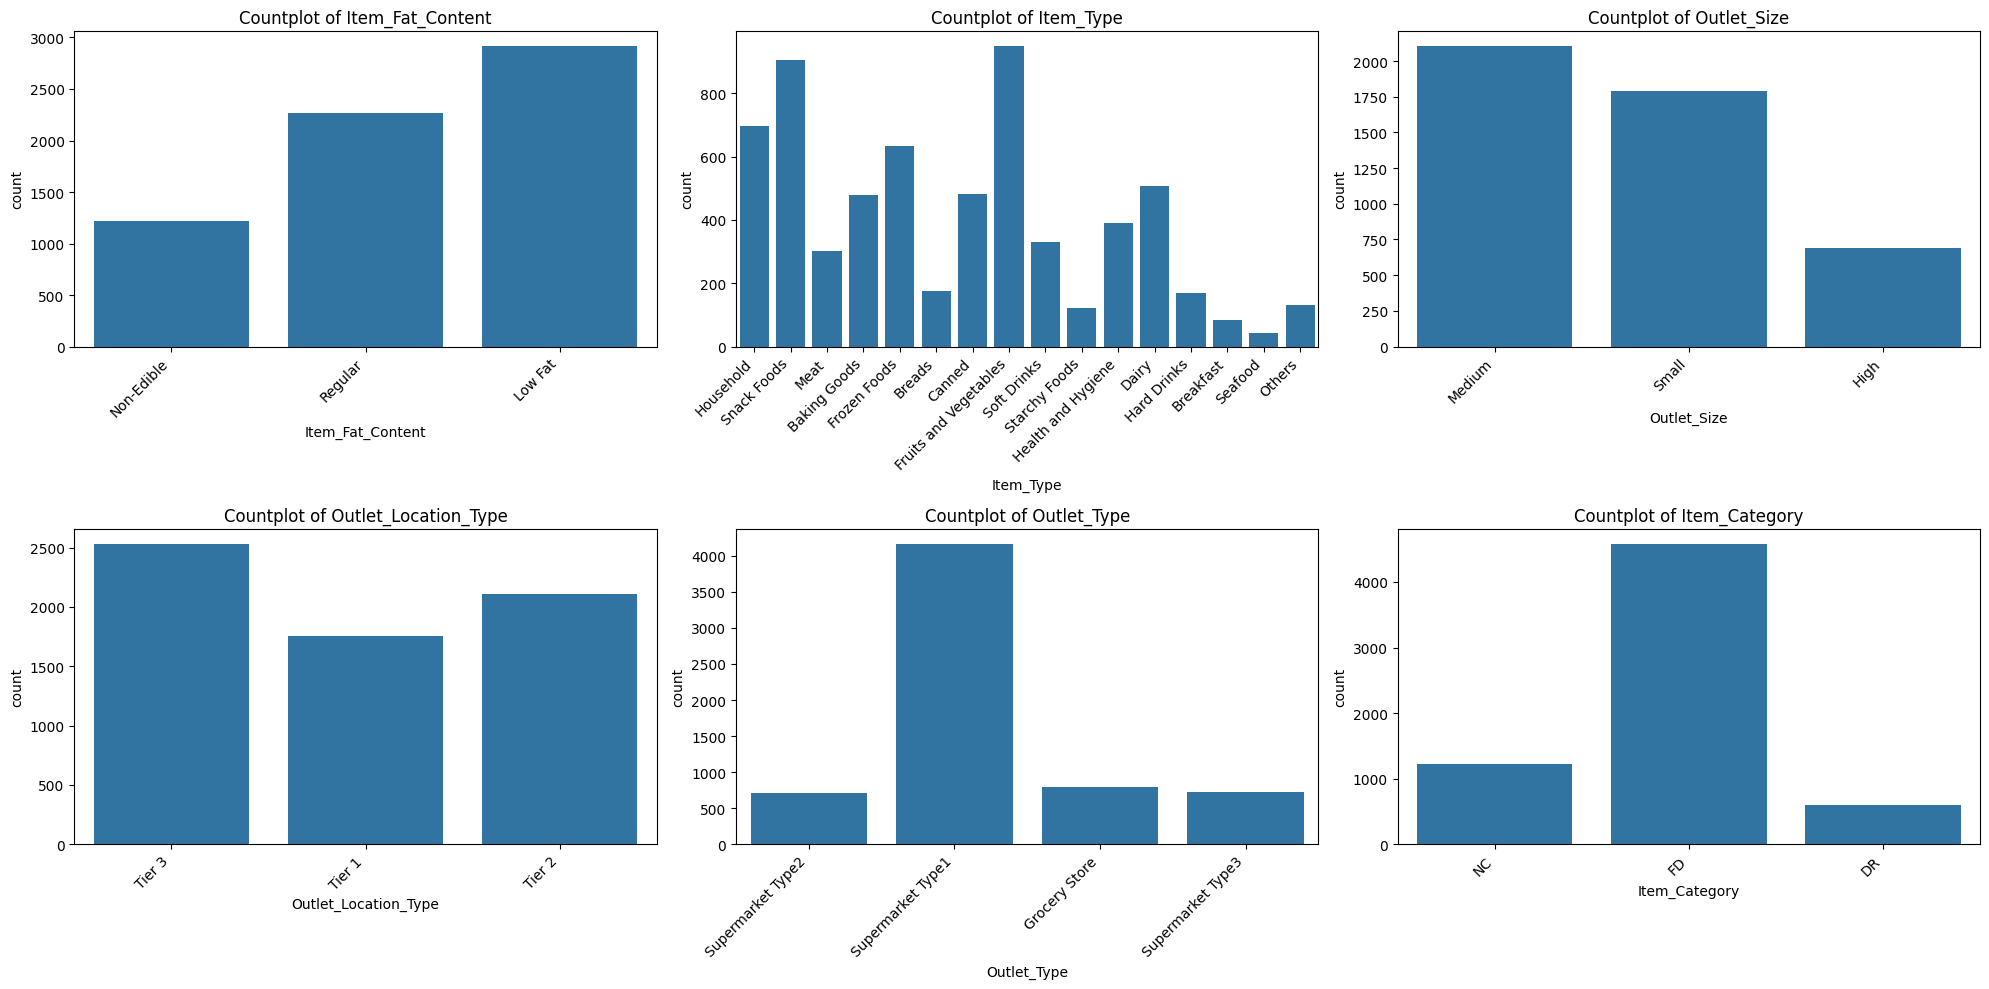

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=X_train, x=col, ax=axes[i])

    axes[i].set_title(f"Countplot of {col}")
    axes[i].tick_params(axis='x', labelrotation=45)

    # Right-align labels
    for label in axes[i].get_xticklabels():
        label.set_ha('right')

fig.tight_layout();

What we notice from the countplots:

- Low Fat items are more common than Regular items.
- Fruits and Vegetables and Snack Foods are the most common item types.
- Seafood and Breakfast items are the least common.
- Most outlets are Medium or Small in size.
- Tier 3 locations have the most outlets.
- Supermarket Type1 is much more common than the other outlet types.

### Correlation Heatmap


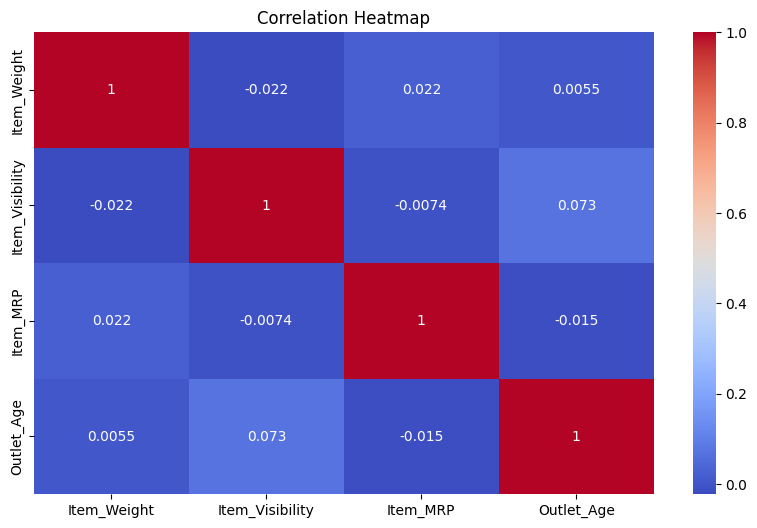

In [ ]:
corr = X_train.corr(numeric_only=True)
plt.figure(figsize=(10,6))
ax = sns.heatmap(corr, annot=True, cmap='coolwarm')
ax.set_title("Correlation Heatmap");

### Regression Plot: Maximum Retail Price & Item Outlet Sales

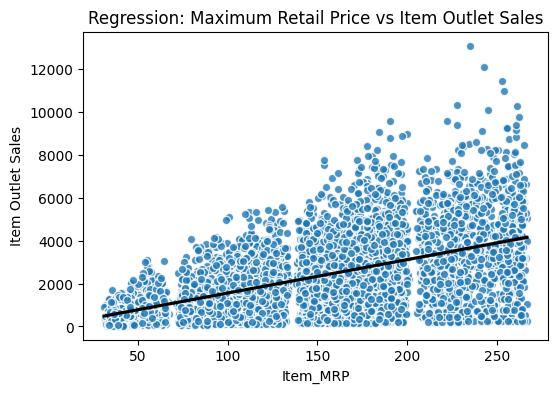

In [ ]:
plt.figure(figsize=(6,4))
line_kws = dict(color='black')
scatter_kws = dict(edgecolor='white')

# To correctly plot Item_MRP vs Item_Outlet_Sales, we need to combine X_train and y_train for the plot.
# Alternatively, we can ensure the data passed to sns.regplot contains both columns.
# Since y_train is a Series, we can plot against Item_MRP from X_train directly if indices align.

# Create a temporary DataFrame for plotting if necessary, or ensure direct access
plot_df = pd.DataFrame({'Item_MRP': X_train['Item_MRP'], 'Item_Outlet_Sales': y_train})

ax = sns.regplot(
    data=plot_df,
    x='Item_MRP',
    y='Item_Outlet_Sales',
    line_kws=line_kws,
    scatter_kws=scatter_kws
)

ax.set(
    xlabel="Item_MRP",
    ylabel="Item Outlet Sales",
    title="Regression: Maximum Retail Price vs Item Outlet Sales"
);

- There is a positive relationship between Maximum Retail Price and Item Outlet Sales. As retail price increases, sales tend to increase as well.

### Countplot of Item Type

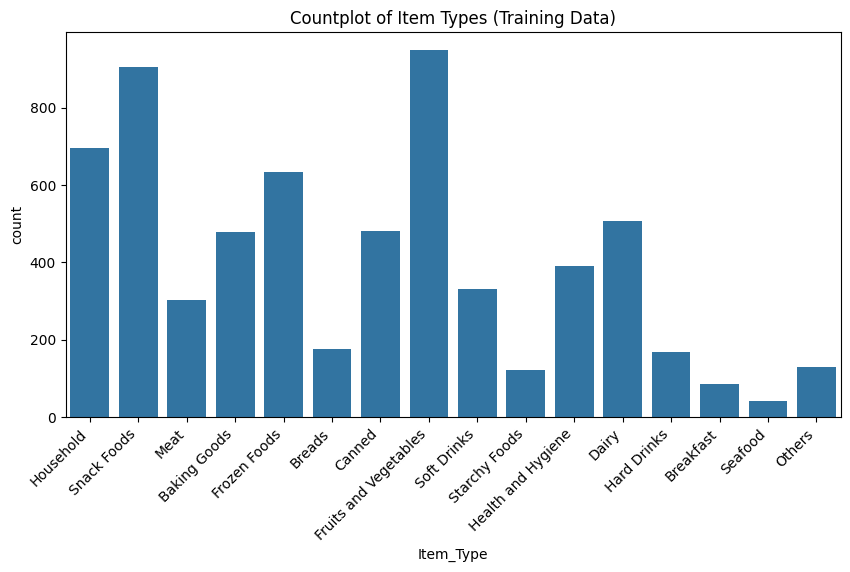

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.countplot(data=X_train, x='Item_Type')

ax.set_title("Countplot of Item Types (Training Data)");

plt.xticks(rotation=45, ha='right');

- Fruits and Vegetables and Snack Foods are the most common item categories, while Seafood and Breakfast items appear least frequently.

### OutletType vs Sales

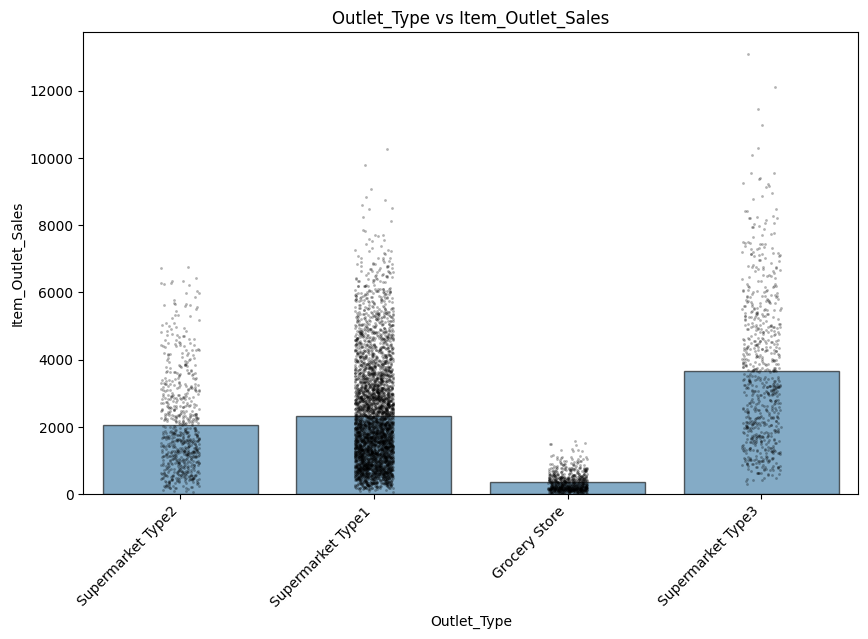

In [ ]:
train_df = X_train.copy()
train_df["Item_Outlet_Sales"] = y_train

plt.figure(figsize=(10, 6))

sns.barplot(
    data=train_df,
    x="Outlet_Type",
    y="Item_Outlet_Sales",
    errorbar=None,
    alpha=0.6,
    edgecolor="black"
)

sns.stripplot(
    data=train_df,
    x="Outlet_Type",
    y="Item_Outlet_Sales",
    color="black",
    alpha=0.3,
    size=2,
    jitter=True
)

plt.title("Outlet_Type vs Item_Outlet_Sales")
plt.xticks(rotation=45, ha="right");

- Supermarket Type3 has the highest average `Item_Outlet_Sales`.
- Grocery Stores have the lowest average sales.
- Supermarket Type1 and Type3 have greater variation in sales and include several high-selling products.
- `Outlet_Type` has a strong relationship with `Item_Outlet_Sales`, making it an important feature for predicting sales.

## Preprocessing

### Ordinal Pipleline

In [ ]:
# see value counts for possible ordinal features
ord_cols=['Outlet_Size']
X_train[ord_cols].value_counts(dropna=False)

,count
Outlet_Size,
Medium,2103
NaN,1812
Small,1788
High,689


In [ ]:
# order cats
size_order=['MISSING','Small','Medium','High']
# Pipeline
ord_pipe = make_pipeline(
  SimpleImputer(strategy='constant', fill_value='MISSING'),
  OrdinalEncoder(categories=[size_order]),
  StandardScaler()
)
ord_tuple = ('Ordinal', ord_pipe, ord_cols)

ord_pipe

Pipeline(steps=[('simpleimputer',
                 SimpleImputer(fill_value='MISSING', strategy='constant')),
                ('ordinalencoder',
                 OrdinalEncoder(categories=[['MISSING', 'Small', 'Medium',
                                             'High']])),
                ('standardscaler', StandardScaler())])

### Nominal Pipeline

In [ ]:
ohe_cols = X_train.select_dtypes('object').drop(columns=ord_cols).columns
ohe_pipe = make_pipeline(
  SimpleImputer(strategy='constant', fill_value='NA'),
  OneHotEncoder(sparse_output=False, handle_unknown='ignore')
)

ohe_tuple = ('Categorical', ohe_pipe, ohe_cols)
ohe_pipe

Pipeline(steps=[('simpleimputer',
                 SimpleImputer(fill_value='NA', strategy='constant')),
                ('onehotencoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

### Numeric Pipeline

In [ ]:
num_cols_train= make_column_selector(dtype_include="number")
# Item_Visibility's 0s are now replaced with np.nan before this pipeline step
num_pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
num_tuple = ('Numeric', num_pipe, num_cols_train)

num_pipe

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

### Creating Preprocessor

In [ ]:
preprocessor = ColumnTransformer(
  [num_tuple, ord_tuple, ohe_tuple],
  verbose_feature_names_out=False
)

### Model Evaluation Function

In [ ]:

def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = mse ** 0.5
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae,
                 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics

def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                        output_frame=False):
  y_train_pred = reg.predict(X_train)

  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                     output_dict=output_frame,
                                     label='Training Data')
  print()
  y_test_pred = reg.predict(X_test)
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,
                                  output_dict=output_frame,
                                    label='Test Data' )

  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    results_df = results_df.set_index('Label')
    results_df.index.name=None
    return results_df.round(3)

## Model: Linear Regression

In [ ]:
# linear regression

linreg_pipe = make_pipeline(preprocessor, LinearRegression())

# Fit on raw training data
linreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('Numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7be7dd48b890>),
                                                 ('Ordinal',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 stra...
                                                 ('Categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='NA',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Location_Type', 'Outlet_Type',
       'Item_Category'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('linearregression', LinearRegression())])

In [ ]:
evaluate_regression(linreg_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 847.252
- MSE = 1,298,229.501
- RMSE = 1,139.399
- R^2 = 0.561

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 804.517
- MSE = 1,195,485.790
- RMSE = 1,093.383
- R^2 = 0.567


- The model does not appear to be overfit or underfit.
- The training R^2 (0.561) and test R^2 (0.567) are very close, indicating that it generalizes well to unseen data. However, since both values are only around 0.56, the model provides a moderate fit and could potentially be improved with better features or a more complex model

## Model: Random Forest

In [ ]:
rf = RandomForestRegressor(random_state=42)
rf_pipe = make_pipeline(preprocessor, rf)

rf_pipe.fit(X_train, y_train)
evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 299.265
- MSE = 186,952.377
- RMSE = 432.380
- R^2 = 0.937

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 777.214
- MSE = 1,248,588.066
- RMSE = 1,117.402
- R^2 = 0.547


- The Random Forest model is overfitting. Its training R^2 score (0.938) is much higher than its test (0.540), meaning that it has memorized the training data and does not generalize as well to new data

- Although the Random Forest has a slightly lower MAE, the Linear Regression model has better overall test performance because it has:
  - Lower MSE
  - Lower RMSE
  - Higher R²

### Tuning with GridCV

In [ ]:
params = {
    'randomforestregressor__max_depth': [None,5, 10, 15, 20],
    'randomforestregressor__n_estimators': [ 100, 150, 200, 300, 500],
    'randomforestregressor__min_samples_leaf': [1, 2, 4,6],
    'randomforestregressor__max_features': ['sqrt', 'log2', None],
    'randomforestregressor__oob_score': [True, False],
    'randomforestregressor__min_samples_split': [2, 5, 10]
}

# 5x5x4x3x2x3 = 1800 combinations x 3 folds = 5400 fits

gridsearch = GridSearchCV(rf_pipe, params, n_jobs=-1, cv=3, verbose=1)
gridsearch.fit(X_train, y_train)

print('\n',gridsearch.best_params_,'\n')

# Best model
best_rf = gridsearch.best_estimator_
evaluate_regression(best_rf, X_train, y_train, X_test, y_test)

Fitting 3 folds for each of 1800 candidates, totalling 5400 fits

 {'randomforestregressor__max_depth': 5, 'randomforestregressor__max_features': None, 'randomforestregressor__min_samples_leaf': 2, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 100, 'randomforestregressor__oob_score': True} 

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 755.505
- MSE = 1,152,234.495
- RMSE = 1,073.422
- R^2 = 0.611

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 728.641
- MSE = 1,096,798.476
- RMSE = 1,047.281
- R^2 = 0.602


In [ ]:
rf = RandomForestRegressor(random_state=42,
                           max_depth=5, max_features=None,
                           min_samples_leaf=2,
                           n_estimators=100,
                           oob_score=True)
rf_pipe = make_pipeline(preprocessor, rf)

rf_pipe.fit(X_train, y_train)
score= evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 755.505
- MSE = 1,152,234.495
- RMSE = 1,073.422
- R^2 = 0.611

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 728.641
- MSE = 1,096,798.476
- RMSE = 1,047.281
- R^2 = 0.602


## **Evaluation**
###**Model Recommendation: Random Forest**

- I recommend the **Random Forest model** for deployment.
  - It outperforms Linear Regression on every test metric: lower MAE, MSE, RMSE, and higher R^2 (0.602 vs 0.567).
  - It shows minimal overfitting, with train/test R^2 nearly identical (0.611 vs 0.602), meaning it's genuinely capturing patterns, not memorizing.

###**R^2 for a non-technical stakeholder**

Our model explains about 60% of the variation in sales using the input features.

- Of every 10 "reasons" sales go up or down, our model accounts for about 6.
- The remaining 40% comes from factors not in our data such as market conditions, promotions, randomness.

###**Selected Metric: RMSE (Root Mean Squared Error)**

I chose RMSE since it's in the same units as sales, making it directly interpretable.
- Our Random Forest model has an RMSE of ~1,047 on test data where predictions are off by about 1,047 sales units on average.
- It penalizes large errors more, which matters since badly underestimating high-sale periods is costlier than small misses.


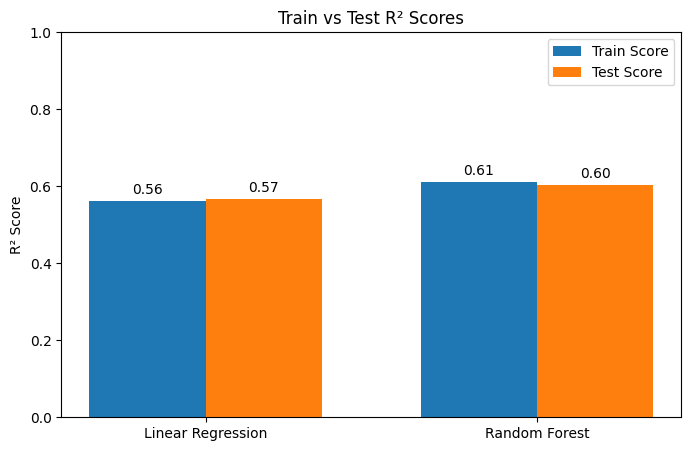

In [ ]:
models = ['Linear Regression', 'Random Forest']

# Preprocess for Random Forest
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

train_scores = [linreg_pipe.score(X_train, y_train), rf.score(X_train_processed, y_train)]
test_scores = [linreg_pipe.score(X_test, y_test), rf.score(X_test_processed, y_test)]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width/2, train_scores, width, label='Train Score')
bars2 = plt.bar(x + width/2, test_scores, width, label='Test Score')

plt.xticks(x, models)
plt.ylabel('R² Score')
plt.title('Train vs Test R² Scores')
plt.legend()
plt.ylim(0, 1)

plt.bar_label(bars1, fmt='%.2f', padding=3)
plt.bar_label(bars2, fmt='%.2f', padding=3);


###**Training vs. Test Performance: Overfitting/Underfitting Check**

The model is **not overfit**.
- Test performance is essentially equal to training performance.
- RMSE is slightly lower on test, R^2 drops slightly
- This means Random Forest generalizes well to unseen data.

- No sign of underfitting either, both models explain similar variance (R^2 ~0.56–0.61), suggesting this is near the practical ceiling for the current features.
- Next step to improve: better/more features rather than a more complex model.